# Cell-cell communication: ligand-receptor vs NCEM

**Block 2** | Two families of method try to answer the same question: is one cell's
behaviour shaped by who is next to it? They start from opposite ends. Ligand-receptor
inference starts from prior knowledge of which genes physically interact. Node-centric
expression modelling (NCEM) starts from no prior knowledge at all and asks the data
directly: does a cell's expression depend on the composition of its neighbourhood?

The central point of this notebook comes first, before any spatial method: permute the
coordinates and watch a standard (non-spatial) LR analysis not notice.


## Setup

Same QC-filtered Xenium object as the rest of Block 1/2/3, with the marker-based cell type
annotation from notebook 1.


In [1]:
%matplotlib inline

import pathlib
import sys

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))


In [2]:
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import liana as li
from scipy import stats
from scipy.linalg import lstsq
from scipy.spatial import cKDTree

import paths

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Changing the sparsity structure")
warnings.filterwarnings("ignore", message="zero-centering a sparse")

import logging
logging.getLogger("ome_zarr").setLevel(logging.WARNING)

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
adata = sdata["table"]
adata.obs["control_fraction"] = (
    adata.obs[["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]].sum(axis=1)
    / adata.obs["total_counts"].clip(lower=1)
)
keep = (
    (adata.obs["total_counts"] >= 10)
    & (adata.obs["nucleus_count"] >= 1)
    & (adata.obs["control_fraction"] <= 0.05)
)
adata = adata[keep].copy()
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

celltype_file = paths.precomputed("xenium_celltypes.h5ad")
if celltype_file is not None:
    adata.obs["cell_type"] = ad.read_h5ad(celltype_file).obs["cell_type"].reindex(adata.obs_names)
    print(f"cell types loaded from cache: {celltype_file}")
else:
    # Same procedure as notebook 1, section 1, repeated here so this notebook runs
    # standalone from a fresh kernel, matching Day 1's convention.
    print("cell type cache not found, recomputing (see notebook 1 for the full explanation)")
    markers = {
        "epithelial_tumor": ["EPCAM", "KRT8", "KRT7", "CDH1", "ESR1", "PGR", "ERBB2", "GATA3",
                             "FOXA1", "TACSTD2", "MLPH", "ANKRD30A", "AGR3", "S100A14", "CEACAM6", "TPD52"],
        "myoepithelial": ["ACTA2", "MYH11", "MYLK", "KRT14", "KRT5", "OXTR"],
        "t_nk_cell": ["CD3E", "CD3G", "CD247", "CD4", "CD8A", "IL7R", "TRAC", "TCF7", "CTLA4",
                      "FOXP3", "GNLY", "NKG7", "KLRD1", "KLRF1", "KLRC1", "PRF1", "GZMA", "GZMK", "KLRB1", "CCL5"],
        "b_plasma_cell": ["MS4A1", "CD79A", "CD79B", "CD19", "BANK1", "TCL1A", "MZB1", "TNFRSF17", "PRDM1", "SLAMF7"],
        "myeloid": ["CD68", "CD14", "CD163", "LYZ", "C1QA", "C1QC", "ITGAM", "ITGAX", "MRC1",
                    "FCGR3A", "AIF1", "MNDA", "APOC1", "FCER1G"],
        "mast_cell": ["TPSAB1", "CPA3", "CTSG", "KIT"],
        "dendritic_cell": ["CLEC9A", "FCER1A", "LILRA4", "IL3RA", "CLECL1"],
        "endothelial": ["PECAM1", "VWF", "CLEC14A", "EGFL7", "RAMP2", "AQP1", "SOX17", "SOX18",
                         "KDR", "MMRN2", "ESM1", "NOSTRIN", "CD93"],
        "fibroblast_stromal": ["PDGFRA", "PDGFRB", "LUM", "FBLN1", "POSTN", "DPT", "SFRP4",
                                "SFRP1", "MMP2", "CXCL12", "LRRC15", "CCDC80"],
        "adipocyte": ["ADIPOQ", "LPL", "UCP1", "PPARG"],
    }
    scaled = adata.copy()
    sc.pp.scale(scaled, max_value=10)
    sc.pp.pca(scaled, n_comps=50)
    sc.pp.neighbors(scaled)
    sc.tl.leiden(scaled, resolution=1.0, flavor="igraph", n_iterations=2, random_state=0)
    Xs = pd.DataFrame(scaled.X, columns=scaled.var_names, index=scaled.obs_names)
    mean_expr = pd.DataFrame({name: Xs[genes].mean(axis=1) for name, genes in markers.items()})
    mean_expr["leiden"] = scaled.obs["leiden"].values
    cluster_mean = mean_expr.groupby("leiden").mean()
    sorted_vals = np.sort(cluster_mean.values, axis=1)
    margin = sorted_vals[:, -1] - sorted_vals[:, -2]
    top_label = cluster_mean.idxmax(axis=1)
    final_label = top_label.where(margin >= 0.15, other="epithelial_tumor")
    adata.obs["cell_type"] = scaled.obs["leiden"].map(final_label).astype("category")
cell_types = sorted(adata.obs["cell_type"].cat.categories.tolist())
print(f"{adata.n_obs} cells after QC, {len(cell_types)} cell types")


no parent found for <ome_zarr.reader.Label object at 0x7d9cdf6cf0b0>: None


no parent found for <ome_zarr.reader.Label object at 0x7d9cdc511c70>: None


cell types loaded from cache: /opt/workshop/data/precomputed/xenium_celltypes.h5ad
6906 cells after QC, 6 cell types


## 0. The risk to check first

Sender/receiver methods need enough cells of *each type* to say anything. With 6,906 cells
in two fields of view, some types are thin.


In [3]:
counts = adata.obs["cell_type"].value_counts()
print(counts)
print()
print(f"smallest type: {counts.idxmin()} (n={counts.min()}), treat pairs involving it as illustrative, not conclusive")


cell_type
epithelial_tumor      5446
myeloid                595
fibroblast_stromal     569
t_nk_cell              190
endothelial             67
myoepithelial           39
Name: count, dtype: int64

smallest type: myoepithelial (n=39), treat pairs involving it as illustrative, not conclusive


Two types (`myoepithelial`, n=39; `endothelial`, n=67) are thin enough that any
sender/receiver pair involving them as the *receiver* is running a regression on well under
a hundred points split across six predictors. This is a limitation of a two-FOV crop, not a
teaching simplification; state it plainly rather than restricting silently. The rest of
this notebook uses `t_nk_cell` (n=190) as the receiver of interest, which is thin but usable.


## 1. Permute the coordinates, before anything spatial

A standard (non-spatial) LR analysis groups cells by type and compares expression between
groups. It never looks at `obsm["spatial"]`. Run it once on the real coordinates, permute
the coordinates, and run it again: nothing about the grouping or the expression changed, so
nothing about the result should either.


In [4]:
li.mt.rank_aggregate(adata, groupby="cell_type", expr_prop=0.1, n_perms=None, use_raw=False, verbose=False)
res_real = adata.uns["liana_res"].copy()

adata_perm = adata.copy()
rng = np.random.default_rng(0)
perm_idx = rng.permutation(adata_perm.n_obs)
adata_perm.obsm["spatial"] = adata_perm.obsm["spatial"][perm_idx]
li.mt.rank_aggregate(adata_perm, groupby="cell_type", expr_prop=0.1, n_perms=None, use_raw=False, verbose=False)
res_perm = adata_perm.uns["liana_res"].copy()

merged = res_real.merge(res_perm, on=["source", "target", "ligand_complex", "receptor_complex"], suffixes=("_real", "_perm"))
max_diff = (merged["magnitude_rank_real"] - merged["magnitude_rank_perm"]).abs().max()
print(f"max |difference| in magnitude_rank after permuting coordinates: {max_diff:.6f}")
print()
print("top 5 pairs, real coordinates:")
print(res_real.sort_values("magnitude_rank").head(5)[["source", "target", "ligand_complex", "receptor_complex", "magnitude_rank"]])


/opt/workshop/physalia/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


/opt/workshop/physalia/.pixi/envs/default/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


max |difference| in magnitude_rank after permuting coordinates: 0.000000

top 5 pairs, real coordinates:
                 source       target ligand_complex receptor_complex  \
48   fibroblast_stromal  endothelial           MMP2           PECAM1   
2           endothelial  endothelial           MMP2           PECAM1   
62   fibroblast_stromal      myeloid         CXCL12              CD4   
151           t_nk_cell  endothelial           MMP2           PECAM1   
75   fibroblast_stromal    t_nk_cell         CXCL12            CXCR4   

     magnitude_rank  
48         0.000259  
2          0.001033  
62         0.002316  
151        0.004103  
75         0.006387  


The difference is exactly zero. This is not a subtle result; it is the whole point. A
non-spatial LR score is a statement about *which cell types* express complementary genes,
never about *whether they are ever near each other*. Everything after this point in the
notebook is about closing that gap.

> **_Question:_** `fibroblast_stromal -> endothelial` via `MMP2/PECAM1` scores near the top.
> Would you trust that pair more or less than a pair between two cell types that are
> abundant but rarely adjacent? What would you need to check?


## 2. Spatially weighted LR, three bandwidths

`li.ut.spatial_neighbors` builds a distance-weighted connectivity graph (a Gaussian kernel
here, not kNN or Delaunay: a different graph family from the niche-detection notebook, same
underlying principle). `li.mt.bivariate` then scores each ligand-receptor pair *locally*, per
cell, as well as with a global Moran's I. Same pair, three bandwidths: which map would you publish?


In [5]:
bandwidths = [10, 50, 150]
bivar_results = {}
for bw in bandwidths:
    a = adata.copy()
    li.ut.spatial_neighbors(a, bandwidth=bw, cutoff=0.1, kernel="gaussian", set_diag=True)
    out = li.mt.bivariate(
        a, local_name="cosine", global_name="morans", resource_name="consensus",
        n_perms=100, seed=0, nz_prop=0.05, use_raw=False, verbose=False,
    )
    bivar_results[bw] = out
    top = out.var.sort_values("morans", ascending=False)
    print(f"bandwidth={bw:>3}um  top pair: {top.index[0]}  Moran's I={top['morans'].iloc[0]:.3f}")


bandwidth= 10um  top pair: CXCL12^CD4  Moran's I=0.221


bandwidth= 50um  top pair: CXCL12^CD4  Moran's I=0.243


bandwidth=150um  top pair: CXCL12^CD4  Moran's I=0.265


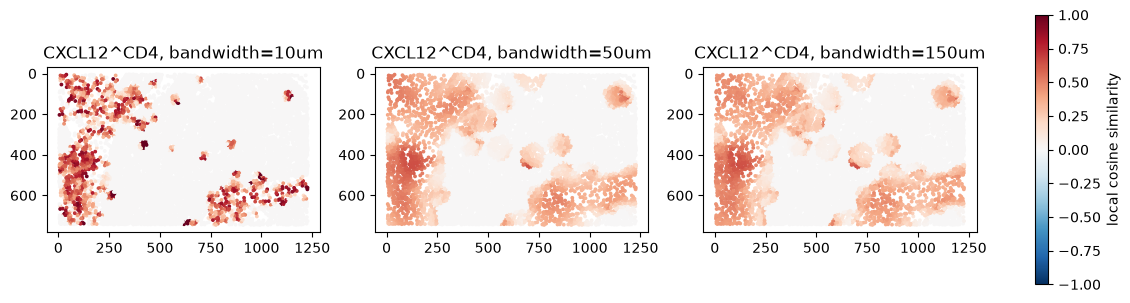

In [6]:
pair = "CXCL12^CD4"
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, bw in zip(axes, bandwidths):
    out = bivar_results[bw]
    x = out[:, pair].X
    score = np.asarray(x.todense()).flatten() if hasattr(x, "todense") else np.asarray(x).flatten()
    sc_ax = ax.scatter(adata.obsm["spatial"][:, 0], adata.obsm["spatial"][:, 1], c=score, s=3, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(f"{pair}, bandwidth={bw}um")
    ax.set_aspect("equal")
    ax.invert_yaxis()
plt.colorbar(sc_ax, ax=axes, shrink=0.7, label="local cosine similarity")
plt.show()


The same interaction score gets progressively smoother as the bandwidth grows: real local
structure at 10 μm can be smeared into a tissue-scale gradient by 150 μm. There is no bandwidth
that is simply "correct"; the choice states a hypothesis about the physical range over which
you believe this signalling acts.


## 3. Linear NCEM from scratch

`statsmodels` is not in this environment on purpose. Building the regression by hand means
seeing the design matrix directly: for a chosen *receiver* cell type, each row is one
receiver cell, each column is the fraction of one *sender* cell type among that cell's
spatial neighbours within radius `R`, and the response is the receiver's expression of one
gene.

**A design choice worth pausing on:** the neighbourhood fractions already sum to 1 for every
cell, so adding a separate intercept column creates exact collinearity (the classic dummy
variable trap): the fractions alone already span that direction. Drop the intercept and
keep all six fractions; each coefficient is then directly interpretable as "expected
expression if 100% of this cell's neighbours were this type".


In [7]:
def neighborhood_composition(adata, radius, cell_types, type_col="cell_type"):
    xy = adata.obsm["spatial"]
    tree = cKDTree(xy)
    pairs = tree.query_pairs(r=radius, output_type="ndarray")
    n = adata.n_obs
    type_codes = adata.obs[type_col].astype(pd.CategoricalDtype(categories=cell_types)).cat.codes.values
    comp = np.zeros((n, len(cell_types)))
    if len(pairs):
        a_idx, b_idx = pairs[:, 0], pairs[:, 1]
        np.add.at(comp, (a_idx, type_codes[b_idx]), 1)
        np.add.at(comp, (b_idx, type_codes[a_idx]), 1)
    totals = comp.sum(axis=1, keepdims=True)
    frac = np.divide(comp, totals, out=np.zeros_like(comp), where=totals > 0)
    return frac, totals.flatten()


def linear_ncem(adata, receiver_type, target_gene, radius, cell_types, type_col="cell_type", min_neighbors=3):
    """Least squares + hand-derived t-statistics: y = neighbourhood composition @ beta, no intercept."""
    frac, n_neighbors = neighborhood_composition(adata, radius, cell_types, type_col)
    mask = (adata.obs[type_col].values == receiver_type) & (n_neighbors >= min_neighbors)
    X = frac[mask]
    y = adata[:, target_gene].X
    y = np.asarray(y.todense()).flatten()[mask] if hasattr(y, "todense") else np.asarray(y).flatten()[mask]

    beta, _, rank, _ = lstsq(X, y)
    resid = y - X @ beta
    n, p = X.shape
    dof = n - p
    sigma2 = (resid @ resid) / dof
    se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(X.T @ X)))
    t_stats = beta / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - (resid ** 2).sum() / ss_tot if ss_tot > 0 else np.nan
    table = pd.DataFrame({"coef": beta, "t": t_stats, "p": p_values}, index=cell_types)
    return table, r2, n


In [8]:
table, r2, n = linear_ncem(adata, receiver_type="t_nk_cell", target_gene="LYZ", radius=50, cell_types=cell_types)
print(f"receiver=t_nk_cell  target=LYZ  radius=50um  n={n}  R2={r2:.3f}")
table.round(4)


receiver=t_nk_cell  target=LYZ  radius=50um  n=190  R2=0.254


,coef,t,p
endothelial,1.4562,0.7421,0.4590
epithelial_tumor,0.1845,0.5885,0.5569
fibroblast_stromal,0.2997,0.7628,0.4466
myeloid,2.6699,11.7312,0.0000
myoepithelial,1.0853,0.3722,0.7102
t_nk_cell,-0.7028,-1.1221,0.2633


`LYZ` is a myeloid marker; T and NK cells have no biological reason to transcribe it. The
`myeloid` neighbour fraction is nonetheless the only coefficient that survives (t≈12,
p≈0): T/NK cells sitting next to more myeloid cells show more `LYZ` signal. Hold that
thought for the pitfalls section.


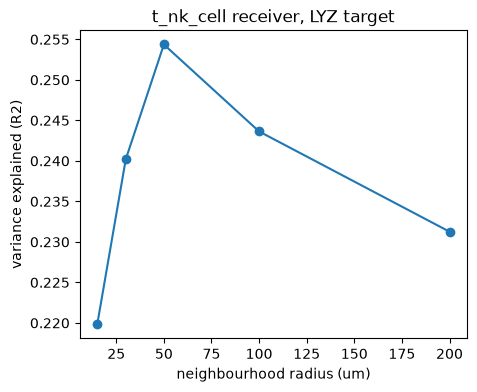

In [9]:
radii = [15, 30, 50, 100, 200]
r2_by_radius = []
for radius in radii:
    _, r2_r, _ = linear_ncem(adata, "t_nk_cell", "LYZ", radius, cell_types)
    r2_by_radius.append(r2_r)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(radii, r2_by_radius, marker="o")
ax.set_xlabel("neighbourhood radius (um)")
ax.set_ylabel("variance explained (R2)")
ax.set_title("t_nk_cell receiver, LYZ target")
plt.show()


R2 peaks around 50 μm and softens at larger radii. Connect this back to the niche-detection notebook: at large
`R`, the neighbourhood-composition vector stops describing "who touches this cell" and starts
describing "which spatial domain this cell is in": the same fraction vector a niche method
would produce. NCEM and niche detection converge as the radius grows; report the radius you
used, because it determines which question you actually answered.


## 4. Shuffle cell type labels, coordinates fixed

If the coupling above reflects the real spatial arrangement, randomly reassigning which
cell has which type, while leaving every cell exactly where it is, should destroy it.


In [10]:
rng = np.random.default_rng(0)
n_shuffles = 20
shuffled_r2 = []
for _ in range(n_shuffles):
    shuffled_labels = adata.obs["cell_type"].astype(str).to_numpy().copy()
    rng.shuffle(shuffled_labels)
    adata.obs["cell_type_shuffled"] = pd.Categorical(shuffled_labels, categories=cell_types)
    _, r2_s, _ = linear_ncem(adata, "t_nk_cell", "LYZ", 50, cell_types, type_col="cell_type_shuffled")
    shuffled_r2.append(r2_s)

print(f"real labels:      R2 = {r2:.3f}")
print(f"shuffled labels:  R2 = {np.mean(shuffled_r2):.3f} +/- {np.std(shuffled_r2):.3f}  (n={n_shuffles} shuffles)")


real labels:      R2 = 0.254
shuffled labels:  R2 = 0.059 +/- 0.021  (n=20 shuffles)


Most of the coupling does not survive: a real result, not an artefact of having six free
parameters and a small sample.

**But check this before trusting any single gene/receiver pair.** Repeating the same test with
`receiver="t_nk_cell", target="CXCR4"` gives real R2 ≈ 0.05 against a shuffled mean of ≈ 0.05,
indistinguishable from noise, despite `CXCR4` showing up as a strong spatial LR hit in
section 2. R2 from a six-parameter regression on 190 points is noisy; treat any single
(receiver, gene, radius) result as a lead to check with the shuffle test, not a finding on
its own.

> **_Question:_** Why might `CXCR4` (a receptor with an established ligand pair in the LR
> analysis above) show weaker NCEM coupling than `LYZ` (a marker gene with no plausible
> ligand-receptor story for T/NK cells at all)?


## 5. Segmentation spillover

The `LYZ`-in-T-cells result is not a curiosity: it is close to the textbook signature of
**segmentation spillover**: at a boundary between a T/NK cell and a myeloid cell, some
`LYZ` transcripts get assigned to the wrong cell simply because the segmentation drew the
boundary a few micrometres off. That manufactures *exactly* the neighbour-dependent
expression pattern NCEM is designed to detect: a T cell's apparent expression depends on
who is next to it, but for a boundary-drawing reason, not a signalling one.

Neither LR inference nor NCEM can rule this out on their own; both report an association
between neighbours and expression regardless of *why* it exists. The distinction matters:
before publishing a coupling result, check whether the affected gene is a strong,
cell-type-defining marker for the *neighbour* type; if it is, look at the segmentation
boundaries (Day 1, Session 2.1/2.2) before you look for biology.


### Exercise

Pick one of `endothelial` or `myoepithelial` as the receiver type (both under 70 cells).
Run the radius sweep from section 3 with any target gene, and compare the R2 curve's
noisiness to the `t_nk_cell` result above. Is a coefficient's t-statistic still
interpretable at this sample size?


In [11]:
# your answer here


## Pitfalls

- **Non-spatial LR scores never see coordinates.** Permuting them is a free, five-line
  sanity check; run it before trusting any non-spatial LR result on spatial data.
- **A regression's R2 is not automatically evidence of real coupling.** Compare against a
  label-shuffled null before reporting a single (receiver, gene, radius) result; section 4
  shows both a result that survives and one that does not.
- **Neighbourhood composition and niche membership converge at large radius.** Report the
  radius; a large one answers a different question than a small one.
- **A marker gene for the neighbour's cell type showing up in the receiver is a segmentation
  red flag, not automatically a communication finding.**

## Further reading

- [LIANA+ documentation](https://liana-py.readthedocs.io/) and the bivariate/spatial tutorials
- Fischer, D.S. et al. (2021), *Modeling intercellular communication in tissues using
  spatial graphs of cells*, on which NCEM is based (package not used here: TensorFlow,
  unmaintained since 2023, but the linear model is the same idea)
- MISTy (Tanevski et al. 2022) for a multi-view knowledge-free alternative
